In [6]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

You should consider upgrading via the 'c:\Users\ASUS\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

In [8]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
df.shape

(74682, 4)

In [17]:
df['Sentiment'].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

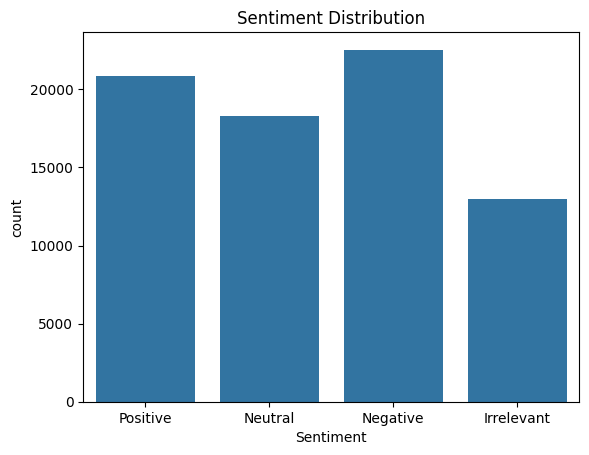

In [19]:
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [21]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

df['Clean_Text'] = df['Text'].apply(clean_text)

In [23]:
stop_words = set(stopwords.words('english'))

df['Clean_Text'] = df['Clean_Text'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

In [25]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['Clean_Text'])
y = df['Sentiment']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6834036285733414
              precision    recall  f1-score   support

  Irrelevant       0.68      0.52      0.59      2592
    Negative       0.74      0.77      0.75      4519
     Neutral       0.61      0.64      0.62      3596
    Positive       0.69      0.72      0.71      4230

    accuracy                           0.68     14937
   macro avg       0.68      0.66      0.67     14937
weighted avg       0.68      0.68      0.68     14937



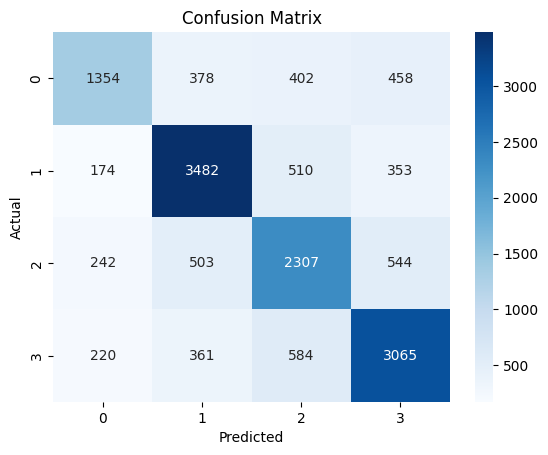

In [34]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


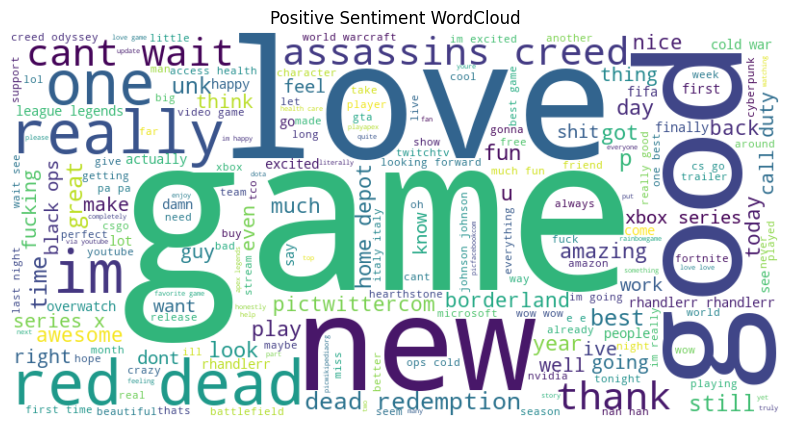

In [35]:
positive_text = " ".join(df[df['Sentiment']=='Positive']['Clean_Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Sentiment WordCloud")
plt.show()